In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

from skimage.measure import regionprops, label
from skimage.feature import graycomatrix, graycoprops

BASE_DIR = Path("..")
DATASET_DIR = BASE_DIR / "dataset_binario"
OUTPUT_DIR = BASE_DIR / "outputs"

X_PATH = OUTPUT_DIR / "X.csv"
Y_PATH = OUTPUT_DIR / "y.csv"

In [2]:
def segmentar_hsv(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # TODO: substituir pelos valores ajustados pela equipe.
    lower = np.array([0, 20, 20])
    upper = np.array([40, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5, 5), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask


def manter_maior_contorno(mask):
    contornos, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contornos) == 0:
        return mask

    maior = max(contornos, key=cv2.contourArea)

    mask_limpa = np.zeros_like(mask)
    cv2.drawContours(mask_limpa, [maior], -1, 255, thickness=-1)

    return mask_limpa

In [3]:
def extrair_features_forma(mask):
    """
    Extrai features geométricas do grão.
    """

    props = regionprops(label(mask > 0))

    if len(props) == 0:
        return None

    regiao = max(props, key=lambda r: r.area)

    area = regiao.area
    perimeter = regiao.perimeter
    eccentricity = regiao.eccentricity
    solidity = regiao.solidity
    extent = regiao.extent

    if perimeter > 0:
        circularity = 4 * np.pi * area / (perimeter ** 2)
    else:
        circularity = 0

    return {
        "area": area,
        "perimeter": perimeter,
        "eccentricity": eccentricity,
        "solidity": solidity,
        "extent": extent,
        "circularity": circularity
    }

In [4]:
def extrair_momentos_hu(mask):
    """
    Extrai os 7 momentos de Hu em escala logarítmica.
    """

    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()

    hu_log = []

    for valor in hu:
        if valor == 0:
            hu_log.append(0)
        else:
            hu_log.append(-np.sign(valor) * np.log10(abs(valor)))

    return {
        f"hu_{i+1}": hu_log[i]
        for i in range(7)
    }

In [5]:
def extrair_features_cor(img_bgr, mask):
    """
    Calcula médias e desvios de cor usando somente a região do grão.
    """

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    pixels_rgb = img_rgb[mask > 0]
    pixels_hsv = img_hsv[mask > 0]

    if len(pixels_rgb) == 0:
        return None

    mean_r, mean_g, mean_b = pixels_rgb.mean(axis=0)
    std_r, std_g, std_b = pixels_rgb.std(axis=0)

    mean_h, mean_s, mean_v = pixels_hsv.mean(axis=0)
    std_h, std_s, std_v = pixels_hsv.std(axis=0)

    return {
        "mean_r": mean_r,
        "mean_g": mean_g,
        "mean_b": mean_b,
        "std_r": std_r,
        "std_g": std_g,
        "std_b": std_b,
        "mean_h": mean_h,
        "mean_s": mean_s,
        "mean_v": mean_v,
        "std_h": std_h,
        "std_s": std_s,
        "std_v": std_v
    }

In [6]:
def extrair_features_textura(img_bgr, mask):
    """
    Extrai propriedades de textura usando GLCM.
    """

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Mantém apenas a região do grão.
    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)

    # TODO: recortar a região do grão para evitar muito fundo preto.
    # Dica: use cv2.boundingRect no maior contorno.

    glcm = graycomatrix(
        gray_masked,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy = graycoprops(glcm, "energy")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]

    return {
        "glcm_contrast": contrast,
        "glcm_homogeneity": homogeneity,
        "glcm_energy": energy,
        "glcm_correlation": correlation
    }

In [7]:
def extrair_features_imagem(img_path):
    img_bgr = cv2.imread(str(img_path))

    if img_bgr is None:
        return None

    mask = segmentar_hsv(img_bgr)
    mask = manter_maior_contorno(mask)

    features_forma = extrair_features_forma(mask)
    features_hu = extrair_momentos_hu(mask)
    features_cor = extrair_features_cor(img_bgr, mask)
    features_textura = extrair_features_textura(img_bgr, mask)

    if (
        features_forma is None
        or features_hu is None
        or features_cor is None
        or features_textura is None
    ):
        return None

    features = {}

    features.update(features_forma)
    features.update(features_hu)
    features.update(features_cor)
    features.update(features_textura)

    return features

In [8]:
linhas_X = []
linhas_y = []

classes = ["ok", "defeituoso"]

for classe in classes:
    pasta_classe = DATASET_DIR / classe

    for img_path in pasta_classe.glob("*"):
        features = extrair_features_imagem(img_path)

        if features is None:
            print(f"Erro ao processar: {img_path}")
            continue

        features["filename"] = img_path.name

        linhas_X.append(features)

        linhas_y.append({
            "filename": img_path.name,
            "classe": classe
        })

X = pd.DataFrame(linhas_X)
y = pd.DataFrame(linhas_y)

X.to_csv(X_PATH, index=False)
y.to_csv(Y_PATH, index=False)

display(X.head())
display(y.head())

,area,perimeter,eccentricity,solidity,extent,circularity,hu_1,hu_2,hu_3,hu_4,...,mean_s,mean_v,std_h,std_s,std_v,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,filename
0,22530.0,587.102597,0.636820,0.982384,0.782292,0.821378,3.189597,7.568356,12.246394,13.907437,...,121.103995,137.294363,2.150730,33.554711,42.155828,36.178605,0.925572,0.909096,0.985262,ok_0001.jpg
1,20797.0,556.658946,0.707934,0.988263,0.777749,0.843397,3.178690,7.308915,12.451936,13.916229,...,133.809492,113.264125,1.744677,33.742155,38.612502,35.917948,0.934725,0.915882,0.975293,ok_0002.jpg
2,102383.0,2818.862048,0.602502,0.833154,0.639894,0.161916,3.103542,7.515344,9.773206,11.187986,...,61.791342,145.430443,2.615328,62.863116,35.688969,167.842846,0.805253,0.587619,0.984183,ok_0003.jpg
3,248932.0,2105.656854,0.123631,0.995728,0.995728,0.705530,3.184315,10.595523,13.518844,15.469881,...,35.302822,135.910401,2.359543,36.398519,25.334779,2.830553,0.847890,0.089254,0.998249,ok_0004.jpg
4,22989.0,582.173665,0.639746,0.985848,0.809016,0.852363,3.189384,7.557926,13.015358,14.725995,...,138.424812,84.948280,2.417938,38.286195,32.376966,42.099551,0.924247,0.907265,0.959571,ok_0005.jpg


,filename,classe
0,ok_0001.jpg,ok
1,ok_0002.jpg,ok
2,ok_0003.jpg,ok
3,ok_0004.jpg,ok
4,ok_0005.jpg,ok


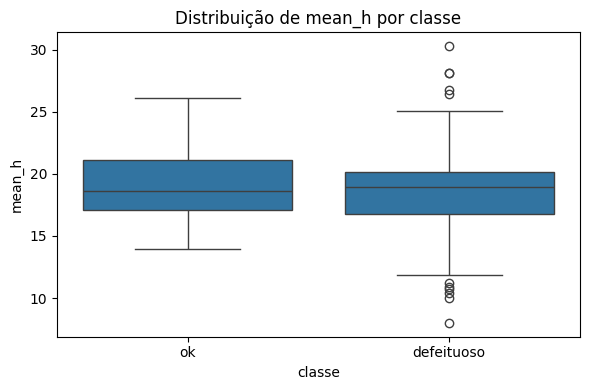

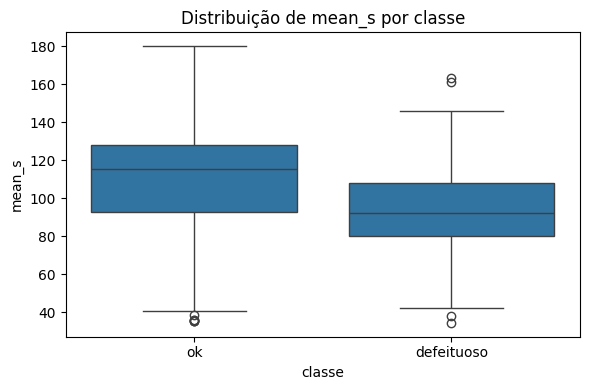

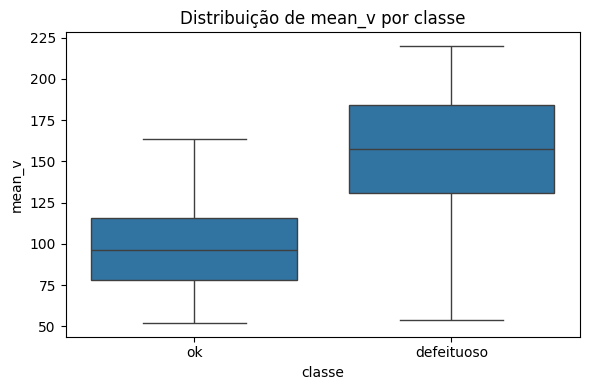

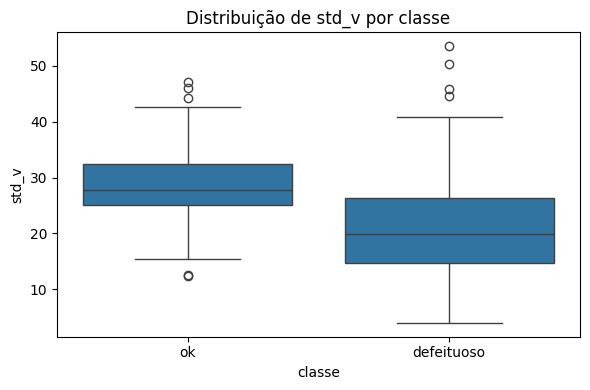

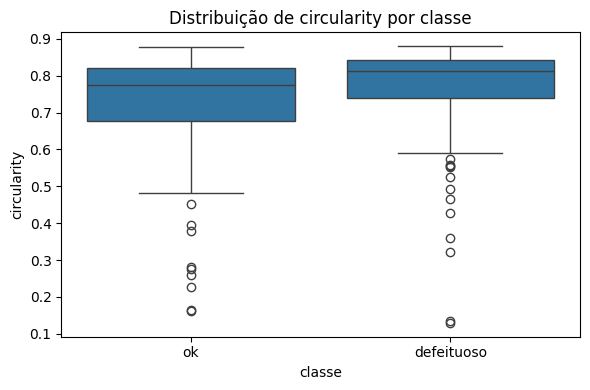

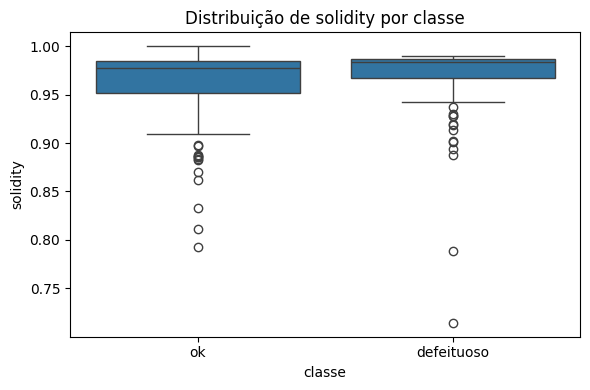

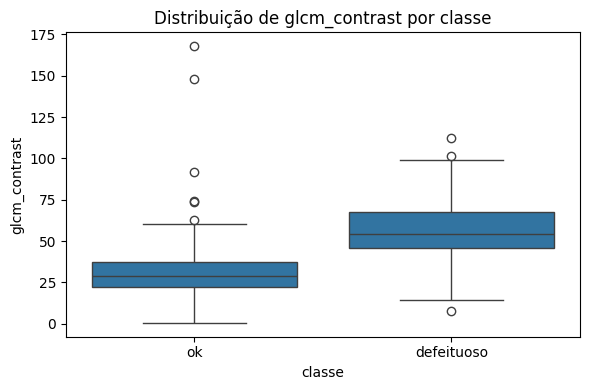

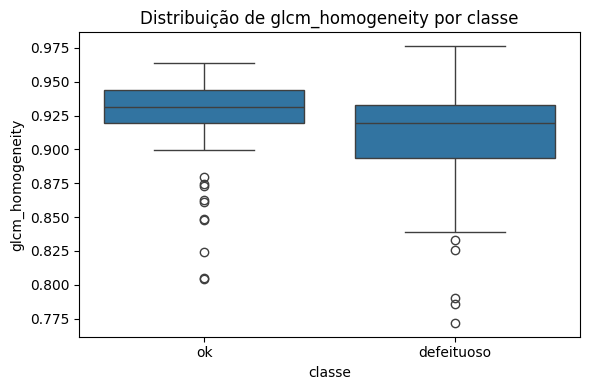

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

df = X.merge(y, on="filename")

features_para_plotar = [
    "mean_h",
    "mean_s",
    "mean_v",
    "std_v",
    "circularity",
    "solidity",
    "glcm_contrast",
    "glcm_homogeneity"
]

for feature in features_para_plotar:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="classe", y=feature)
    plt.title(f"Distribuição de {feature} por classe")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "graficos_features" / f"boxplot_{feature}.png")
    plt.show()